# Vizuálne transformery a hybridné štruktúry na klasifikáciu obrazov

**Predmet:** Hlboké neurónové siete (HNS)

Tento notebook nadväzuje na notebook `01_attention_a_transformery.ipynb`, kde sme
mechanizmus pozornosti postavili od nuly a použili ho na generovanie textu.
Teraz ten istý mechanizmus prenesieme na **obrazové dáta**.

### Čo si prejdeme

| Časť | Téma |
|------|------|
| 1 | Prečo sa self-attention nedá použiť priamo na pixely |
| 2 | Patch embedding: ako z obrázka spraviť sekvenciu tokenov |
| 3 | CLS token a pozičné embeddingy |
| 4 | Multi-head self-attention nad patchmi (bez kauzálnej masky) |
| 5 | Zloženie mini-ViT od nuly |
| 6 | Tréning ViT od nuly: prečo zlyháva na malých dátach |
| 7 | Predtrénovaný ViT (DeiT-Tiny): fine-tuning |
| 8 | Hierarchické ViT: Swin Transformer |
| 9 | ConvNeXt: CNN modernizovaná podľa transformerov |
| 10 | CBAM: pridanie pozornosti do konvolučnej siete |
| 11 | Hybridné architektúry: CoAtNet |

Kompletné porovnanie všetkých architektúr na spoločnom datasete je
v notebooku `03_porovnanie_modelov.ipynb`.

In [1]:
import math, os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)
np.random.seed(1337)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('zariadenie:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

zariadenie: cuda
GPU: NVIDIA GeForce RTX 4070 Ti


## 1. Prečo sa self-attention nedá pustiť priamo na pixely

V notebooku 01 bol vstupom text, prirodzená **sekvencia** tokenov. Obrázok je
ale 2D mriežka pixelov. Najpriamočiarejšia myšlienka „ber každý pixel ako jeden
token" narazí na zložitosť self-attention.

Pre sekvenciu dĺžky $n$ počíta self-attention maticu skóre $n \times n$:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

Pamäť aj čas rastú ako $O(n^2)$. Pozrime sa, čo to znamená pre bežný obrázok.

In [2]:
H = W = 224
n_pixels = H * W                 # kazdy pixel = jeden token
n_patches = (H // 16) * (W // 16)  # patche 16x16 = jeden token

for name, n in [('pixely ako tokeny', n_pixels), ('patche 16x16 ako tokeny', n_patches)]:
    # matica skore n x n vo float32
    mem_gb = n * n * 4 / 1024**3
    print(f'{name:26s} n = {n:6d}   matica skore {n}x{n}   ~{mem_gb:10.4f} GB (1 hlava, 1 obrazok)')

print(f'\npomer: patchovanie znizi velkost matice skore {(n_pixels/n_patches)**2:,.0f}x')

pixely ako tokeny          n =  50176   matica skore 50176x50176   ~    9.3789 GB (1 hlava, 1 obrazok)
patche 16x16 ako tokeny    n =    196   matica skore 196x196   ~    0.0001 GB (1 hlava, 1 obrazok)

pomer: patchovanie znizi velkost matice skore 65,536x


Matica pozornosti nad pixelmi by pre **jeden obrázok a jednu hlavu** zabrala
takmer 10 GB. To je dôvod, prečo Vision Transformer (Dosovitskiy et al., 2020)
obraz najprv rozdelí na **patche**: neprekrývajúce sa štvorce $16 \times 16$
pixelov. Z $224 \times 224$ obrázka tak vznikne sekvencia 196 tokenov, čo je
dĺžka, akú transformer bez problémov zvládne.

## 2. Patch embedding: z obrázka sekvencia tokenov

Postup má tri kroky:

1. obrázok $(3, 224, 224)$ rozrežeme na mriežku $14 \times 14$ patchov veľkosti $16\times16$,
2. každý patch sploštíme na vektor dĺžky $16 \cdot 16 \cdot 3 = 768$,
3. lineárnou vrstvou ho premietneme do dimenzie modelu $D$.

Kľúčové pozorovanie: kroky 1–3 sa dajú spraviť **jedinou konvolúciou**
s veľkosťou jadra aj krokom rovným veľkosti patchu. Nižšie si overíme, že obe
cesty dávajú identický výsledok.

In [3]:
def patchify_manual(imgs, patch_size=16):
    '''Rozdeli obrazok na patche 'rucne' cez unfold a splosti ich.'''
    B, C, H, W = imgs.shape
    # (B, C, H, W) -> (B, C, H/p, W/p, p, p)
    x = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    # -> (B, pocet_patchov, C*p*p)
    x = x.permute(0, 2, 3, 1, 4, 5).contiguous()
    return x.view(B, -1, C * patch_size * patch_size)


class PatchEmbedding(nn.Module):
    '''Rozdelenie na patche + linearna projekcia, realizovane konvoluciou.'''
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        # kernel_size == stride == patch_size -> kazdy patch sa spracuje prave raz
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)              # (B, D, grid, grid)
        x = x.flatten(2)              # (B, D, num_patches)
        return x.transpose(1, 2)      # (B, num_patches, D)


img = torch.randn(2, 3, 224, 224)
pe = PatchEmbedding(embed_dim=192)
tokens = pe(img)
print('vstup            ', tuple(img.shape))
print('rucne patche     ', tuple(patchify_manual(img).shape), '  (este bez projekcie)')
print('po patch embed   ', tuple(tokens.shape), '  (B, pocet_patchov, D)')
print('pocet patchov    ', pe.num_patches, f'= {pe.grid_size}x{pe.grid_size}')

vstup             (2, 3, 224, 224)
rucne patche      (2, 196, 768)   (este bez projekcie)
po patch embed    (2, 196, 192)   (B, pocet_patchov, D)
pocet patchov     196 = 14x14


In [4]:
# Overenie: konvolucia so stride=patch_size je naozaj len linearna vrstva nad patchom
manual = patchify_manual(img)                                  # (B, N, 768)
W_flat = pe.proj.weight.view(pe.proj.out_channels, -1)         # (D, 768)
manual_proj = manual @ W_flat.T + pe.proj.bias                 # (B, N, D)

print('maximalny rozdiel medzi conv a rucnou projekciou:',
      (manual_proj - tokens).abs().max().item())
print('-> konvolucia so stride = patch_size JE patch embedding')

maximalny rozdiel medzi conv a rucnou projekciou: 2.6226043701171875e-06
-> konvolucia so stride = patch_size JE patch embedding


### Ako to vyzerá na reálnom obrázku

Načítame jeden obrázok z datasetu Food-101 a ukážeme mriežku patchov, ktoré
z neho vzniknú. Práve tieto štvorce sú „slová", ktoré transformer uvidí.

trieda: churros | tvar: (3, 224, 224)


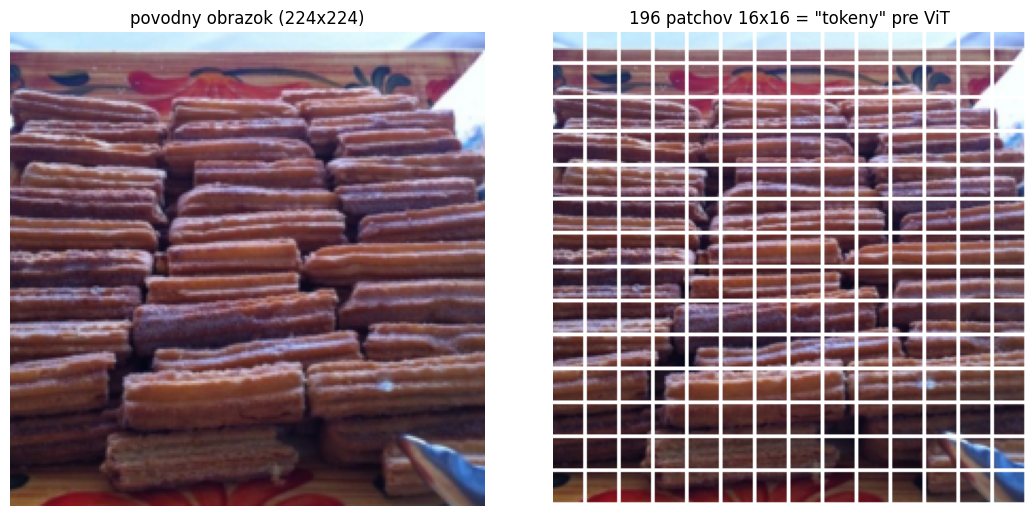

In [5]:
from torchvision.datasets import Food101
from torchvision import transforms

DATA_ROOT = '/home/user/ROK1/Kajan/HNS_materialy/data'
food = Food101(root=DATA_ROOT, split='test', download=False)

to_tensor = transforms.Compose([transforms.Resize(256),
                                transforms.CenterCrop(224),
                                transforms.ToTensor()])
pil_img, label = food[0]
img_t = to_tensor(pil_img)
print('trieda:', food.classes[label], '| tvar:', tuple(img_t.shape))

patches = patchify_manual(img_t.unsqueeze(0))[0]        # (196, 768)
patches_img = patches.view(14, 14, 3, 16, 16)           # spat na obrazky

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
axes[0].imshow(img_t.permute(1, 2, 0)); axes[0].set_title('povodny obrazok (224x224)')
axes[0].axis('off')

# mriezka 14x14 patchov s medzerami, aby bolo delenie viditelne
canvas = np.ones((14 * 18, 14 * 18, 3))
for i in range(14):
    for j in range(14):
        canvas[i*18:i*18+16, j*18:j*18+16] = patches_img[i, j].permute(1, 2, 0).numpy()
axes[1].imshow(canvas); axes[1].set_title('196 patchov 16x16 = "tokeny" pre ViT')
axes[1].axis('off')
plt.tight_layout(); plt.show()

## 3. CLS token a pozičné embeddingy

Po patch embeddingu máme sekvenciu 196 vektorov. Chýbajú dve veci:

**Pozičná informácia.** Self-attention je *permutačne ekvivariantná*: keby sme
patche premiešali, výstup by sa len premiešal rovnako. Sieť by teda nevedela,
ktorý patch bol vľavo hore. Preto ku každému tokenu pripočítame naučený
**pozičný embedding**. (V notebooku 01 sme robili presne to isté cez
`position_embedding_table`.)

**Jeden vektor reprezentujúci celý obrázok.** Na klasifikáciu potrebujeme jeden
vektor, nie 196. ViT preto pridá na začiatok sekvencie špeciálny naučený
**CLS token**. Ten sa cez vrstvy attention „napozerá" na všetky patche a jeho
finálny stav ide do klasifikačnej hlavy.

In [6]:
class ViTEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=192, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        n = self.patch_embed.num_patches
        # naucene parametre: CLS token a pozicne embeddingy (n patchov + 1 CLS)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        self.drop = nn.Dropout(dropout)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                             # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        return self.drop(x + self.pos_embed)                # + pozicia


emb = ViTEmbedding(embed_dim=192)
out = emb(torch.randn(2, 3, 224, 224))
print('po embeddingu:', tuple(out.shape), ' <- 196 patchov + 1 CLS = 197 tokenov')
print('naucene parametre CLS:', emb.cls_token.numel(),
      '| pozicne embeddingy:', emb.pos_embed.numel())

po embeddingu: (2, 197, 192)  <- 196 patchov + 1 CLS = 197 tokenov
naucene parametre CLS: 192 | pozicne embeddingy: 37824


## 4. Multi-head self-attention nad patchmi

Toto je **ten istý** mechanizmus ako v notebooku 01, s jedným podstatným
rozdielom.

V jazykovom modeli (GPT) sme používali **kauzálnu masku**: token nesmel vidieť
budúcnosť, lebo úlohou bolo predpovedať ďalší znak:

```python
wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))   # notebook 01
```

Pri klasifikácii obrazu žiadne „predtým" a „potom" neexistuje. Obrázok je
k dispozícii celý naraz, takže **masku vynecháme** a každý patch sa môže pozerať
na všetky ostatné. To je rozdiel medzi *dekodérovou* (kauzálnou) a *enkodérovou*
(obojsmernou) self-attention.

Nižšie je implementácia s viacerými hlavami spracovanými naraz, namiesto
`nn.ModuleList` hláv (ako v notebooku 01) použijeme jednu maticu pre Q, K, V
a hlavy oddelíme cez `reshape`. Je to matematicky totožné, len rýchlejšie.

In [7]:
class MultiHeadSelfAttention(nn.Module):
    '''Obojsmerna (nemaskovana) multi-head self-attention.'''
    def __init__(self, dim, num_heads=3, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0, 'dim musi byt delitelne poctom hlav'
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5          # 1/sqrt(d_k)
        self.qkv = nn.Linear(dim, dim * 3, bias=True)   # Q, K, V naraz
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        # (B, N, 3D) -> (3, B, hlavy, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale   # (B, hlavy, N, N)
        attn = attn.softmax(dim=-1)                     # ziadna kauzalna maska!
        attn = self.attn_drop(attn)

        x = (attn @ v)                                  # (B, hlavy, N, head_dim)
        x = x.transpose(1, 2).reshape(B, N, D)          # spojenie hlav
        x = self.proj_drop(self.proj(x))
        return (x, attn) if return_attn else x


mhsa = MultiHeadSelfAttention(dim=192, num_heads=3)
y, A = mhsa(out, return_attn=True)
print('vystup       ', tuple(y.shape))
print('mapa attention', tuple(A.shape), ' = (batch, hlavy, tokeny, tokeny)')
print('sucet riadku  ', A[0, 0, 0].sum().item(), '(softmax -> 1.0)')

vystup        (2, 197, 192)
mapa attention (2, 3, 197, 197)  = (batch, hlavy, tokeny, tokeny)
sucet riadku   1.0 (softmax -> 1.0)


### Typy pozornosti: prehľad

| Typ | Odkiaľ Q, K, V | Kde sa používa |
|-----|----------------|----------------|
| **Self-attention** | všetko z tej istej sekvencie | ViT, enkodér BERT |
| **Kauzálna (maskovaná) self-attention** | z tej istej sekvencie + maska budúcnosti | GPT, notebook 01 |
| **Cross-attention** | Q z jednej sekvencie, K a V z druhej | dekodér prekladača, DETR, difúzne modely |
| **Multi-head** | $h$ nezávislých podpriestorov paralelne | prakticky všade |
| **Okenná (windowed)** | obmedzená na lokálne okno | Swin Transformer |
| **Kanálová / priestorová (CBAM)** | váhy z agregovaných štatistík, nie z Q·K | CNN + attention |

Prvé štyri sme pokryli v notebooku 01 a vyššie. Okennej sa venuje časť 8,
CBAM časť 10.

## 5. Zloženie mini-ViT

Blok transformera je identický s tým z notebooku 01: *pre-norm* usporiadanie
s dvoma reziduálnymi vetvami:

$$x \leftarrow x + \text{MHSA}(\text{LN}(x)), \qquad x \leftarrow x + \text{MLP}(\text{LN}(x))$$

Jediné odlišnosti oproti GPT bloku: `GELU` namiesto `ReLU` a chýbajúca maska.

In [8]:
class MLP(nn.Module):
    def __init__(self, dim, hidden_ratio=4, drop=0.0):
        super().__init__()
        hidden = int(dim * hidden_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))    # komunikacia medzi patchmi
        x = x + self.mlp(self.norm2(x))     # spracovanie kazdeho patchu zvlast
        return x


class MiniViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=10,
                 embed_dim=192, depth=6, num_heads=3, drop=0.0):
        super().__init__()
        self.embed = ViTEmbedding(img_size, patch_size, embed_dim, drop)
        self.blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads, 4, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])           # klasifikujeme z CLS tokenu

    @torch.no_grad()
    def attention_maps(self, x):
        '''Vrati mapy pozornosti zo vsetkych blokov (na vizualizaciu).'''
        maps = []
        x = self.embed(x)
        for blk in self.blocks:
            h, a = blk.attn(blk.norm1(x), return_attn=True)
            maps.append(a)
            x = x + h
            x = x + blk.mlp(blk.norm2(x))
        return maps


mini = MiniViT(num_classes=10).to(device)
n_par = sum(p.numel() for p in mini.parameters())
print(f'MiniViT: {n_par/1e6:.2f}M parametrov')
print('vystup:', tuple(mini(torch.randn(2, 3, 224, 224, device=device)).shape))

MiniViT: 2.86M parametrov


vystup: (2, 10)


## 6. Tréning ViT od nuly: a prečo na malých dátach zlyháva

Teraz mini-ViT krátko natrénujeme **od nuly** na 10 triedach z Food-101
(6 750 trénovacích obrázkov). (Nejde o to dosiahnuť dobrý výsledok ide o to
uvidieť charakteristický problém)

Konvolučná sieť má zabudované **induktívne biasy**:

- *lokalita* — konvolučné jadro sa pozerá len na svoje okolie,
- *zdieľanie váh* — ten istý filter sa aplikuje na celý obrázok,
- *translačná ekvivariancia* — posun objektu posunie odozvu, nezmení ju.

ViT nemá ani jeden z nich. Vzťah medzi patchmi sa musí **naučiť z dát**, a to
stojí dáta. V pôvodnom článku bolo treba 300M obrázkov (JFT-300M), aby ViT
prekonal CNN. Na 6 750 obrázkoch teda čakáme slabý výsledok.

In [9]:
import sys
sys.path.insert(0, '/home/user/ROK1/Kajan/HNS_materialy/src')
from data import build_datasets, build_loaders, build_transforms, SELECTED_CLASSES

IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf, eval_tf = build_transforms(224, IMAGENET_MEAN, IMAGENET_STD)
train_ds, val_ds, test_ds = build_datasets(train_tf, eval_tf)
train_ld, val_ld, test_ld = build_loaders(train_ds, val_ds, test_ds,
                                          batch_size=64, num_workers=8)
print('triedy:', SELECTED_CLASSES)
print(f'train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

triedy: ['spaghetti_bolognese', 'spaghetti_carbonara', 'ice_cream', 'frozen_yogurt', 'filet_mignon', 'steak', 'pizza', 'sushi', 'caesar_salad', 'chocolate_cake']
train 6750 | val 750 | test 2500


In [10]:
def train_model(model, train_ld, val_ld, epochs=4, lr=3e-4, wd=0.05, tag=''):
    '''Jednoduchy treningovy cyklus s kosinusovym poklesom LR.'''
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    steps = len(train_ld) * epochs
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps,
                                                pct_start=0.25)
    hist = []
    for ep in range(epochs):
        model.train(); t0 = time.time(); corr = tot = 0; run = 0.0
        for x, y in train_ld:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                logits = model(x); loss = crit(logits, y)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            run += loss.item() * y.size(0)
            corr += (logits.argmax(1) == y).sum().item(); tot += y.size(0)
        tr_acc, tr_loss = corr / tot, run / tot

        model.eval(); vc = vt = 0
        with torch.no_grad():
            for x, y in val_ld:
                x, y = x.to(device), y.to(device)
                with torch.autocast('cuda', dtype=torch.bfloat16):
                    p = model(x).argmax(1)
                vc += (p == y).sum().item(); vt += y.size(0)
        va_acc = vc / vt
        hist.append((tr_acc, va_acc))
        print(f'  {tag} epocha {ep+1}/{epochs} | train loss {tr_loss:.3f} '
              f'acc {tr_acc:.3f} | val acc {va_acc:.3f} | {time.time()-t0:.0f}s')
    return hist


print('MiniViT od nuly (bez predtrenovania):')
hist_scratch = train_model(MiniViT(num_classes=10), train_ld, val_ld,
                           epochs=4, lr=3e-4, tag='scratch')

MiniViT od nuly (bez predtrenovania):


  scratch epocha 1/4 | train loss 2.113 acc 0.247 | val acc 0.388 | 4s


  scratch epocha 2/4 | train loss 1.931 acc 0.344 | val acc 0.428 | 3s


  scratch epocha 3/4 | train loss 1.783 acc 0.412 | val acc 0.504 | 3s


  scratch epocha 4/4 | train loss 1.662 acc 0.473 | val acc 0.521 | 3s


Presnosť sa drží nízko — pri 10 triedach je náhodné hádanie 10 %. Sieť sa síce
niečo naučí, ale ďaleko od použiteľnosti. **Toto je očakávaný výsledok**, nie
chyba v kóde: ViT bez predtrénovania a bez veľkého datasetu jednoducho nemá
odkiaľ získať priestorové induktívne biasy.

Riešenia sú v praxi tri: (a) predtrénovať na veľkom datasete a doladiť,
(b) použiť silnú destiláciu a augmentácie (DeiT), (c) vrátiť konvolúcie späť do
architektúry (hybridy, Swin). Postupne si ukážeme všetky tri.

## 7. Predtrénovaný ViT: DeiT-Tiny

**DeiT** (Data-efficient image Transformer, Touvron et al., 2021) ukázal, že ViT
sa dá natrénovať aj na „iba" ImageNet-1k (1,3M obrázkov) — pomocou silných
augmentácií a destilácie z CNN učiteľa. Architektúra je pritom prakticky
totožná s tou, ktorú sme napísali vyššie.

Zoberieme `deit_tiny_patch16_224` predtrénovaný na ImageNet-1k, vymeníme
klasifikačnú hlavu za 10-triednu a doladíme rovnaké 4 epochy ako mini-ViT.

In [11]:
import timm

deit = timm.create_model('deit_tiny_patch16_224.fb_in1k',
                         pretrained=True, num_classes=10)
print(f'DeiT-Tiny: {sum(p.numel() for p in deit.parameters())/1e6:.2f}M parametrov')
print('hlbka:', len(deit.blocks), '| embed_dim:', deit.embed_dim,
      '| hlavy:', deit.blocks[0].attn.num_heads)

print('\nDeiT-Tiny predtrenovany na ImageNet-1k, doladenie:')
hist_deit = train_model(deit, train_ld, val_ld, epochs=4, lr=1e-4, tag='deit')

DeiT-Tiny: 5.53M parametrov
hlbka: 12 | embed_dim: 192 | hlavy: 3

DeiT-Tiny predtrenovany na ImageNet-1k, doladenie:


  deit epocha 1/4 | train loss 1.538 acc 0.545 | val acc 0.821 | 3s


  deit epocha 2/4 | train loss 0.858 acc 0.835 | val acc 0.845 | 4s


  deit epocha 3/4 | train loss 0.732 acc 0.895 | val acc 0.869 | 3s


  deit epocha 4/4 | train loss 0.663 acc 0.930 | val acc 0.872 | 3s


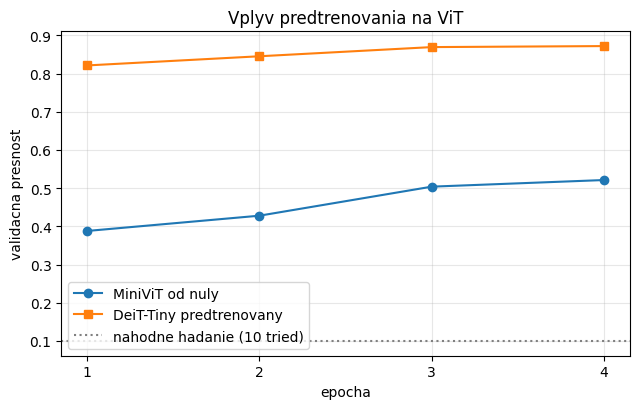

MiniViT od nuly     : 52.1%
DeiT-Tiny doladeny  : 87.2%


In [12]:
ep = range(1, 5)
plt.figure(figsize=(6.5, 4.2))
plt.plot(ep, [h[1] for h in hist_scratch], 'o-', label='MiniViT od nuly')
plt.plot(ep, [h[1] for h in hist_deit], 's-', label='DeiT-Tiny predtrenovany')
plt.axhline(0.1, ls=':', c='gray', label='nahodne hadanie (10 tried)')
plt.xlabel('epocha'); plt.ylabel('validacna presnost'); plt.xticks(list(ep))
plt.title('Vplyv predtrenovania na ViT'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'MiniViT od nuly     : {hist_scratch[-1][1]:.1%}')
print(f'DeiT-Tiny doladeny  : {hist_deit[-1][1]:.1%}')

Rozdiel je dramatický pri takmer rovnakej architektúre a rovnakom rozpočte
epôch. Nesie ho výhradne predtrénovanie.

### Vizualizácia pozornosti: attention rollout

Pekná vlastnosť ViT je, že sa dá priamo pozrieť, **na ktoré patche sa pozerá
CLS token**. Naivné čítanie máp z poslednej vrstvy je ale zavádzajúce, lebo
reziduálne spojenia informáciu miešajú cez vrstvy. **Attention rollout**
(Abnar & Zuidema, 2020) to rieši tak, že mapy pozornosti vynásobí cez všetky
vrstvy a pridá identitu za reziduálne spojenia:

$$\tilde{A}^{(l)} = 0.5\,A^{(l)} + 0.5\,I, \qquad R = \tilde{A}^{(L)} \cdots \tilde{A}^{(1)}$$

nacitane vahy DeiT-Tiny z notebooku 03 (12 epoch)


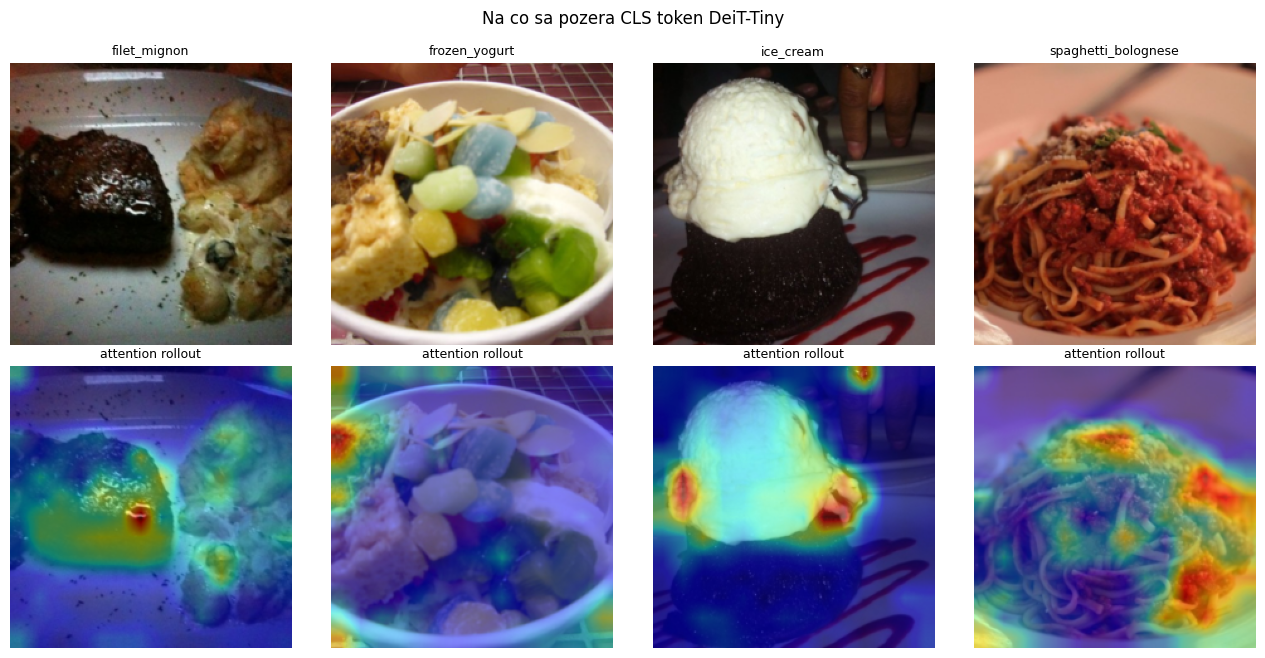

In [13]:
def get_attention_maps(model, x):
    '''Vytiahne mapy pozornosti z kazdeho bloku timm ViT cez forward hooks.'''
    maps, handles = [], []

    def hook(module, inp, out):
        # prepocitame attention z rovnakeho vstupu, aky dostal modul
        B, N, C = inp[0].shape
        qkv = module.qkv(inp[0]).reshape(B, N, 3, module.num_heads,
                                         C // module.num_heads).permute(2, 0, 3, 1, 4)
        q, k = qkv[0], qkv[1]
        attn = (q @ k.transpose(-2, -1)) * module.scale
        maps.append(attn.softmax(dim=-1).detach())

    for blk in model.blocks:
        handles.append(blk.attn.register_forward_hook(hook))
    with torch.no_grad():
        model(x)
    for h in handles:
        h.remove()
    return maps


def attention_rollout(maps, discard_ratio=0.9):
    '''Nasobenie map cez vrstvy s pridanou identitou za rezidualne spojenia.

    Bez zahodenia najslabsich vah je vysledok velmi zasumeny - drobne vahy sa
    cez 12 vrstiev nakumuluju a prekryju signal. Zahadzujeme preto vzdy
    najslabsich `discard_ratio` percent vah v kazdej vrstve (postup z prace
    Abnar & Zuidema a implementacie jacobgil/vit-explain).
    '''
    result = torch.eye(maps[0].size(-1), device=maps[0].device)
    for A in maps:
        A = A.mean(dim=1)[0].clone()             # priemer cez hlavy -> (N, N)
        flat = A.flatten()
        k = int(flat.numel() * discard_ratio)
        if k > 0:
            idx = flat.topk(k, largest=False).indices
            idx = idx[idx != 0]                  # stlpec CLS nechavame
            flat[idx] = 0
        A = flat.view_as(A)
        A = A + torch.eye(A.size(-1), device=A.device)   # rezidualne spojenie
        A = A / A.sum(dim=-1, keepdim=True)
        result = A @ result
    return result[0, 1:]                          # riadok CLS, bez sameho seba


def upsample(heat_2d, size=224):
    '''Hladke zvacsenie mapy 14x14 na velkost obrazka.'''
    t = torch.tensor(heat_2d)[None, None]
    return F.interpolate(t, size=(size, size), mode='bilinear',
                         align_corners=False)[0, 0].numpy()


# Pouzijeme lepsie natrenovane vahy z notebooku 03 (12 epoch), ak existuju -
# mapy su vtedy zretelnejsie nez po 4 epochach vyssie.
DEIT_CKPT = '/home/user/ROK1/Kajan/HNS_materialy/results/checkpoints/deit_tiny.pt'
if os.path.exists(DEIT_CKPT):
    deit.load_state_dict(torch.load(DEIT_CKPT, map_location='cpu'))
    print('nacitane vahy DeiT-Tiny z notebooku 03 (12 epoch)')
deit = deit.to(device).eval()
norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
for col in range(4):
    img_raw, _ = test_ds.base[test_ds.indices[col * 251]]
    x = norm(to_tensor(img_raw)).unsqueeze(0).to(device)
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
        pred = deit(x).argmax(1).item()
    roll = attention_rollout(get_attention_maps(deit, x)).float()
    heat = roll.reshape(14, 14).cpu().numpy()
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

    base = to_tensor(img_raw).permute(1, 2, 0).numpy()
    axes[0, col].imshow(base); axes[0, col].axis('off')
    axes[0, col].set_title(SELECTED_CLASSES[pred], fontsize=9)
    axes[1, col].imshow(base)
    axes[1, col].imshow(upsample(heat), cmap='jet', alpha=0.5)
    axes[1, col].axis('off'); axes[1, col].set_title('attention rollout', fontsize=9)
plt.suptitle('Na co sa pozera CLS token DeiT-Tiny', y=0.99)
plt.tight_layout(); plt.show()

Po zahodení najslabších váh sa mapy sústredia prevažne na **samotné jedlo**:
na steak, na kopček zmrzliny, na cestoviny, a nie na tanier či pozadie. Sieti
to nikto nepovedal explicitne, vyplynulo to len z klasifikačnej straty.

Skúste si `discard_ratio` prepnúť na `0.0` a bunku spustiť znova: mapy sa
rozpadnú na šum. Dôvodom sú takzvané **„attention sink“ tokeny** — pozície, na
ktoré sa pozerá veľká časť hláv bez ohľadu na obsah obrázka. Cez 12 vrstiev sa
ich príspevok nakumuluje a prekryje užitočný signál.

Dôležitá výhrada: attention mapy sú užitočná pomôcka na intuíciu,
ale **nie sú vysvetlením rozhodnutia modelu**. Ukazujú, odkiaľ tečie
informácia, nie čo rozhodlo o triede. Na to slúžia metódy ako Grad-CAM alebo
integrované gradienty.

## 8. Hierarchické ViT: Swin Transformer

Klasický ViT má dva praktické problémy:

1. **kvadratickú zložitosť** v počte patchov, pri vyššom rozlíšení sa to prestane dať počítať,
2. **jednu mierku**: všetky bloky pracujú s mriežkou $14\times14$, takže sieť nemá pyramídu rozlíšení, akú má CNN (a akú potrebuje detekcia či segmentácia).

**Swin Transformer** (Liu et al., 2021) obe rieši:

- self-attention počíta len **v rámci okna** $7\times7$ patchov. Zložitosť tým klesne z $O(n^2)$ na $O(n)$ vzhľadom na počet patchov.
- aby okná neboli izolované, v každom druhom bloku sa mriežka okien **posunie**
  (*shifted window*) o polovicu okna. Informácia sa tak postupne prelieva medzi susednými oknami.
- medzi štádiami sa robí **patch merging**: spojenie $2\times2$ patchov do jedného,
  čím vzniká hierarchia rozlíšení $56\to28\to14\to7$, presne ako stage-e v CNN.

In [14]:
swin = timm.create_model('swin_tiny_patch4_window7_224.ms_in1k',
                         pretrained=True, num_classes=10)
print(f'Swin-Tiny: {sum(p.numel() for p in swin.parameters())/1e6:.2f}M parametrov')

# hierarchia rozliseni - to je ten kluc ovy rozdiel oproti DeiT
feat = timm.create_model('swin_tiny_patch4_window7_224.ms_in1k',
                         pretrained=False, features_only=True)
x = torch.randn(1, 3, 224, 224)
print('\nSwin - pyramida priznakov (ako v CNN):')
for i, f in enumerate(feat(x)):
    print(f'  stage {i}: {tuple(f.shape)}')

print('\nDeiT - stale rovnake rozlisenie:')
with torch.no_grad():
    t = deit.patch_embed(torch.randn(1, 3, 224, 224).to(device))
print(f'  vsetky bloky: {tuple(t.shape)}  (14x14 = 196 patchov)')

Swin-Tiny: 27.53M parametrov

Swin - pyramida priznakov (ako v CNN):


  stage 0: (1, 56, 56, 96)
  stage 1: (1, 28, 28, 192)
  stage 2: (1, 14, 14, 384)
  stage 3: (1, 7, 7, 768)

DeiT - stale rovnake rozlisenie:
  vsetky bloky: (1, 196, 192)  (14x14 = 196 patchov)


In [15]:
# Preco je okenna attention lacnejsia - porovnanie poctu prvkov matice skore
def global_cost(n):   return n * n
def window_cost(n, w=49):  return n * w      # kazdy patch vidi len svoje okno

print(f'{"rozlisenie":>12} {"patchov":>9} {"globalna":>14} {"okenna":>12} {"pomer":>8}')
for side in [14, 28, 56, 112]:
    n = side * side
    g, w = global_cost(n), window_cost(n)
    print(f'{side}x{side:>7} {n:>9,} {g:>14,} {w:>12,} {g/w:>7.0f}x')

  rozlisenie   patchov       globalna       okenna    pomer
14x     14       196         38,416        9,604       4x
28x     28       784        614,656       38,416      16x
56x     56     3,136      9,834,496      153,664      64x
112x    112    12,544    157,351,936      614,656     256x


## 9. ConvNeXt: CNN modernizovaná podľa transformerov

Zaujímavá otázka: koľko z úspechu ViT je zásluha **self-attention** a koľko len
**modernejšieho tréningového receptu a dizajnu**?

**ConvNeXt** (Liu et al., 2022) na to odpovedal experimentom. Zobral obyčajný
ResNet-50 a postupne naň aplikoval jednotlivé prvky zo Swin Transformera,
bez toho, aby pridal čo i len jednu vrstvu attention:

| Zmena | Prevzaté z |
|-------|-----------|
| pomer blokov v štádiách (3,3,9,3) | Swin |
| „patchify" stem — konvolúcia 4×4, stride 4 | ViT patch embedding |
| depthwise konvolúcia 7×7 (namiesto 3×3) | veľké receptívne pole self-attention |
| inverted bottleneck (úzke→široké→úzke) | MLP blok transformera |
| LayerNorm namiesto BatchNorm | transformer |
| GELU namiesto ReLU | transformer |
| menej aktivácií a normalizácií na blok | transformer |
| AdamW, 300 epôch, silné augmentácie | tréningový recept DeiT/Swin |

Výsledok: **čisto konvolučná** sieť dobehla a mierne prekonala Swin. Záver je,
že veľká časť prínosu ViT nebola v samotnej pozornosti, ale v dizajne a tréningu.

In [16]:
convnext = timm.create_model('convnext_tiny.fb_in1k', pretrained=True, num_classes=10)
print(f'ConvNeXt-Tiny: {sum(p.numel() for p in convnext.parameters())/1e6:.2f}M parametrov')

print('\nStruktura jedneho ConvNeXt bloku:')
blk = convnext.stages[0].blocks[0]
for name, mod in blk.named_children():
    print(f'  {name:12s} {mod}')

ConvNeXt-Tiny: 27.83M parametrov

Struktura jedneho ConvNeXt bloku:
  conv_dw      Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
  norm         LayerNorm((96,), eps=1e-06, elementwise_affine=True)
  mlp          Mlp(
  (fc1): Linear(in_features=96, out_features=384, bias=True)
  (act): GELU()
  (drop1): Dropout(p=0.0, inplace=False)
  (norm): Identity()
  (fc2): Linear(in_features=384, out_features=96, bias=True)
  (drop2): Dropout(p=0.0, inplace=False)
)
  shortcut     Identity()
  drop_path    Identity()


In [17]:
# ConvNeXt ma rovnaku pyramidu rozliseni ako Swin
cfeat = timm.create_model('convnext_tiny.fb_in1k', pretrained=False, features_only=True)
print('ConvNeXt - pyramida priznakov:')
for i, f in enumerate(cfeat(torch.randn(1, 3, 224, 224))):
    print(f'  stage {i}: {tuple(f.shape)}')
print('\n-> rovnaka hierarchia ako Swin, ale bez jedinej attention vrstvy')

ConvNeXt - pyramida priznakov:
  stage 0: (1, 96, 56, 56)
  stage 1: (1, 192, 28, 28)
  stage 2: (1, 384, 14, 14)
  stage 3: (1, 768, 7, 7)

-> rovnaka hierarchia ako Swin, ale bez jedinej attention vrstvy


## 10. CBAM: pridanie pozornosti do konvolučnej siete

Existuje aj lacnejšia cesta, ako do CNN dostať pozornosť: nepočítať plnú
self-attention nad tokenmi, ale naučiť sa **preváženie** máp príznakov.

**CBAM** (Convolutional Block Attention Module, Woo et al., 2018) to robí
v dvoch po sebe nasledujúcich krokoch:

**Kanálová pozornosť — „ČO" je dôležité.** Mapu príznakov $F \in \mathbb{R}^{C\times H\times W}$
zagregujeme cez priestor priemerom aj maximom, obe prejdú **zdieľanou** MLP a súčet cez sigmoidu dá váhu pre každý kanál:

$$M_c(F) = \sigma\big(\text{MLP}(\text{AvgPool}(F)) + \text{MLP}(\text{MaxPool}(F))\big) \in \mathbb{R}^{C \times 1 \times 1}$$

**Priestorová pozornosť — „KDE" je to dôležité.** Zagregujeme cez kanály, výsledné dve mapy spojíme a prejdeme jednou konvolúciou $7\times7$:

$$M_s(F) = \sigma\big(f^{7\times7}([\text{AvgPool}_c(F); \text{MaxPool}_c(F)])\big) \in \mathbb{R}^{1 \times H \times W}$$

Celkovo $F'' = M_s(M_c(F) \otimes F) \otimes (M_c(F) \otimes F)$.

Kľúčové z pohľadu praxe: modul **nemení tvar tenzora**, takže sa dá vložiť za
ľubovoľný konvolučný blok, a stojí len zlomok percenta parametrov.

In [18]:
class ChannelAttention(nn.Module):
    ''''CO' je dolezite - vahy pre jednotlive kanaly.'''
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.mlp = nn.Sequential(                      # zdielana MLP ako 1x1 konvolucie
            nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        avg = self.mlp(x.mean(dim=(2, 3), keepdim=True))
        mx  = self.mlp(x.amax(dim=(2, 3), keepdim=True))
        return x * torch.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    ''''KDE' je to dolezite - vaha pre kazdu poziciu.'''
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.amax(dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))


x = torch.randn(2, 96, 56, 56)
cbam = CBAM(96)
print('vstup ', tuple(x.shape), '-> vystup', tuple(cbam(x).shape), ' (tvar sa nemeni)')
print(f'parametre CBAM pre 96 kanalov: {sum(p.numel() for p in cbam.parameters()):,}')

vstup  (2, 96, 56, 56) -> vystup (2, 96, 56, 56)  (tvar sa nemeni)
parametre CBAM pre 96 kanalov: 1,250


### Vloženie CBAM do ConvNeXt

Modul zabalíme za každé zo štyroch štádií ConvNeXt-T (96, 192, 384, 768 kanálov).

In [19]:
class StageWithCBAM(nn.Module):
    '''Obali existujuce stage a za jeho vystup prida CBAM.'''
    def __init__(self, stage, channels, reduction=16):
        super().__init__()
        self.stage = stage
        self.cbam = CBAM(channels, reduction)

    def forward(self, x):
        return self.cbam(self.stage(x))


def add_cbam_to_convnext(model, reduction=16):
    channels = [f['num_chs'] for f in model.feature_info]
    for i, ch in enumerate(channels):
        model.stages[i] = StageWithCBAM(model.stages[i], ch, reduction)
    return model


base = timm.create_model('convnext_tiny.fb_in1k', pretrained=True, num_classes=10)
n_base = sum(p.numel() for p in base.parameters())

cbam_net = add_cbam_to_convnext(
    timm.create_model('convnext_tiny.fb_in1k', pretrained=True, num_classes=10))
n_cbam = sum(p.numel() for p in cbam_net.parameters())

print(f'ConvNeXt-T          : {n_base/1e6:.3f}M parametrov')
print(f'ConvNeXt-T + CBAM   : {n_cbam/1e6:.3f}M parametrov')
print(f'prirastok           : {(n_cbam-n_base)/1e6:.3f}M  '
      f'(+{100*(n_cbam-n_base)/n_base:.2f} %)')
print('\nkanaly stage-ov:', [f['num_chs'] for f in base.feature_info])
print('stage 0 je teraz:', type(cbam_net.stages[0]).__name__)

ConvNeXt-T          : 27.828M parametrov
ConvNeXt-T + CBAM   : 27.926M parametrov
prirastok           : 0.098M  (+0.35 %)

kanaly stage-ov: [96, 192, 384, 768]
stage 0 je teraz: StageWithCBAM


### Ako vyzerá priestorová pozornosť CBAM

Modul je pri vytvorení inicializovaný náhodne, takže má zmysel pozrieť sa naň až
**po tréningu**. Načítame preto váhy natrénované v notebooku 03 a vykreslíme
priestorové mapy z jednotlivých štádií.

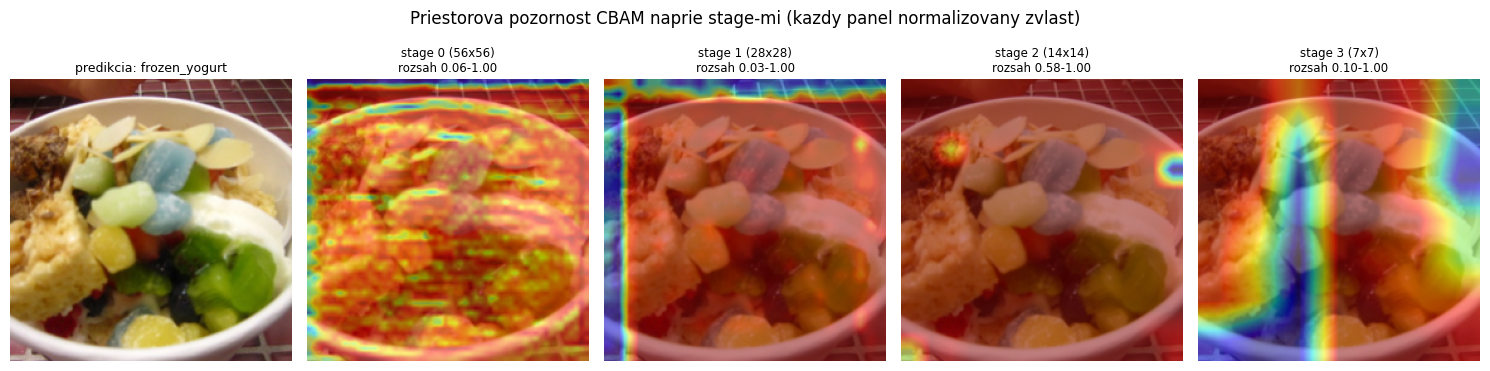

Skutocny rozsah hodnot priestorovej pozornosti po stage-och:
  stage 0: min 0.059  max 0.996  priemer 0.792  smerodajna odchylka 0.148
  stage 1: min 0.035  max 1.000  priemer 0.875  smerodajna odchylka 0.237
  stage 2: min 0.582  max 1.000  priemer 0.994  smerodajna odchylka 0.035
  stage 3: min 0.100  max 0.996  priemer 0.748  smerodajna odchylka 0.316


In [ ]:
import os
CKPT = '/home/user/ROK1/Kajan/HNS_materialy/results/checkpoints/convnext_tiny_cbam.pt'

if os.path.exists(CKPT):
    cbam_net.load_state_dict(torch.load(CKPT, map_location='cpu'))
    cbam_net = cbam_net.to(device).eval()

    # hooks na priestorove mapy zo vsetkych 4 stage-ov
    spatial_maps = []
    def spatial_hook(module, inp, out):
        x = inp[0]
        avg, mx = x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)
        spatial_maps.append(torch.sigmoid(module.conv(torch.cat([avg, mx], 1))).detach())

    handles = [cbam_net.stages[i].cbam.spatial_attention.register_forward_hook(spatial_hook)
               for i in range(4)]

    img_raw, _ = test_ds.base[test_ds.indices[251]]
    x = norm(to_tensor(img_raw)).unsqueeze(0).to(device)
    spatial_maps.clear()
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
        pred = cbam_net(x).argmax(1).item()
    for h in handles:
        h.remove()

    fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))
    axes[0].imshow(to_tensor(img_raw).permute(1, 2, 0)); axes[0].axis('off')
    axes[0].set_title(f'predikcia: {SELECTED_CLASSES[pred]}', fontsize=9)
    for i, m in enumerate(spatial_maps):
        hm = m[0, 0].float().cpu().numpy()
        lo, hi = hm.min(), hm.max()
        # kazdy panel normalizujeme zvlast - inak by sa rozdiely v ramci
        # stage-u stratili, lebo sigmoida vracia hodnoty v uzkom rozsahu
        hm_n = (hm - lo) / (hi - lo + 1e-8)
        axes[i+1].imshow(to_tensor(img_raw).permute(1, 2, 0))
        axes[i+1].imshow(upsample(hm_n), cmap='jet', alpha=0.5)
        axes[i+1].axis('off')
        axes[i+1].set_title(f'stage {i} ({hm.shape[0]}x{hm.shape[1]})\n'
                            f'rozsah {lo:.2f}-{hi:.2f}', fontsize=8.5)
    plt.suptitle('Priestorova pozornost CBAM napriek stage-mi '
                 '(kazdy panel normalizovany zvlast)', y=1.04)
    plt.tight_layout(); plt.show()

    print('Skutocny rozsah hodnot priestorovej pozornosti po stage-och:')
    for i, m in enumerate(spatial_maps):
        hm = m[0, 0].float()
        print(f'  stage {i}: min {hm.min():.3f}  max {hm.max():.3f}  '
              f'priemer {hm.mean():.3f}  smerodajna odchylka {hm.std():.3f}')
else:
    print('Checkpoint zatial neexistuje - najprv spustite notebook 03 '
          '(alebo src/train.py).')

Vypísané štatistiky sú tu zaujímavejšie než samotné obrázky. Priemerné hodnoty
sú **vysoké** (0,75–0,99), takže priestorová pozornosť nefunguje ako ostrá maska
typu „tu áno, tu nie“: väčšinu signálu prepúšťa a len miestami ho tlmí.

Rozdiely medzi štádiami sú pritom výrazné:

- **stage 2** má priemer 0,994 a smerodajnú odchýlku 0,035: mapa je prakticky
  nasýtená na jednotku, čiže priestorová pozornosť tam nerobí takmer nič;
- **stage 3** má odchýlku 0,316, teda zďaleka najväčšiu selektivitu, a to pri
  najhrubšom rozlíšení 7×7, kde sú príznaky najviac sémantické.

Práve preto je každý panel normalizovaný zvlášť, bez toho by stage 2 vyšiel
ako jednoliata plocha.

To dobre vysvetľuje, prečo bol nameraný prínos CBAM malý (+0,4 p.b., notebook
03). Modul nemení, *čo* sieť vidí; len mierne prevažuje kanály a pozície, ktoré
sa už tak javia užitočné. Za 0,35 % parametrov je to rozumný obchod, ale nie je
to náhrada za skutočnú self-attention.

Užitočné cvičenie: porovnať tieto mapy s výstupom Grad-CAM na tej istej sieti,
ukáže sa, že CBAM mapy a mapy dôležitosti pre rozhodnutie nie sú to isté.

## 11. Hybridné architektúry: CoAtNet

Konvolúcie a self-attention majú komplementárne vlastnosti:

| | Konvolúcia | Self-attention |
|---|---|---|
| receptívne pole | lokálne | globálne |
| induktívny bias | silný (lokalita, translácia) | žiadny |
| zložitosť v počte pozícií | $O(n)$ | $O(n^2)$ |
| dátová náročnosť | nízka | vysoká |
| kde je najužitočnejšia | skoré vrstvy, vysoké rozlíšenie | neskoré vrstvy, sémantika |

**CoAtNet** (Dai et al., 2021) z toho robí priamy záver: **konvolúcie dole,
attention hore**. Sieť má štyri štádiá: prvé dve sú MBConv bloky (ako
EfficientNet), posledné dve používajú relatívnu self-attention. Vysoké
rozlíšenie tak spracujú lacné konvolúcie a attention sa zapne až tam, kde je
mriežka dosť malá a príznaky dosť sémantické.

In [21]:
coatnet = timm.create_model('coatnet_0_rw_224.sw_in1k', pretrained=True, num_classes=10)
print(f'CoAtNet-0: {sum(p.numel() for p in coatnet.parameters())/1e6:.2f}M parametrov')

print('\nTypy blokov v jednotlivych stage-och:')
for i, stage in enumerate(coatnet.stages):
    kinds = {type(b).__name__ for b in stage.blocks}
    print(f'  stage {i}: {sorted(kinds)}')
print('\n-> skore stage-e konvolucne (MBConv), neskore s attention')

CoAtNet-0: 26.67M parametrov

Typy blokov v jednotlivych stage-och:
  stage 0: ['MbConvBlock']
  stage 1: ['MbConvBlock']
  stage 2: ['TransformerBlock2d']
  stage 3: ['TransformerBlock2d']

-> skore stage-e konvolucne (MBConv), neskore s attention


## 12. Zhrnutie

Prešli sme celý priestor medzi čistou CNN a čistým transformerom:

```
  cista CNN                                                cisty ViT
     |                                                          |
EfficientNet --- ConvNeXt --- ConvNeXt+CBAM --- CoAtNet --- Swin --- DeiT
     |              |              |               |          |        |
  konvolucie    konvolucie    konvolucie +    konvolucie   okenna   globalna
                modernizovane   lacna         + attention  attention attention
                podla ViT      pozornost
```

Čo si odniesť:

1. **Patch embedding** je len konvolúcia s krokom rovným veľkosti jadra, nič viac.
2. Self-attention pri obraze je **nemaskovaná**, na rozdiel od GPT v notebooku 01.
3. ViT **nemá induktívne biasy CNN**, preto bez predtrénovania na malých dátach zlyháva.
4. **Swin** vracia hierarchiu a lokalitu, čím zníži zložitosť na lineárnu.
5. **ConvNeXt** ukázal, že veľká časť prínosu ViT bola v dizajne a tréningu, nie v pozornosti samotnej.
6. **CBAM** je najlacnejší spôsob, ako do CNN dostať pozornosť — pod pol percenta parametrov navyše.
7. **CoAtNet** kombinuje oboje: konvolúcie dole, attention hore.

Ako si tieto architektúry vedú na spoločnom datasete za rovnakých podmienok,
ukazuje notebook `03_porovnanie_modelov.ipynb`.

### Literatúra

- Vaswani et al. (2017). *Attention Is All You Need.* NeurIPS.
- Dosovitskiy et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* ICLR.
- Touvron et al. (2021). *Training data-efficient image transformers & distillation through attention.* ICML.
- Liu et al. (2021). *Swin Transformer: Hierarchical Vision Transformer using Shifted Windows.* ICCV.
- Liu et al. (2022). *A ConvNet for the 2020s.* CVPR.
- Woo et al. (2018). *CBAM: Convolutional Block Attention Module.* ECCV.
- Dai et al. (2021). *CoAtNet: Marrying Convolution and Attention for All Data Sizes.* NeurIPS.
- Abnar & Zuidema (2020). *Quantifying Attention Flow in Transformers.* ACL.